# A Rota da <span style="color:rebeccapurple">Neuromante</span>

========================================================

# Introdução

A predição de desempenho computacional é um tema relevante, especialmente quando se busca entender como diferentes configurações de um sistema impactam sua performance. Nesse contexto, a taxa de quadros por segundo (FPS) é uma das métricas mais utilizadas para avaliar o desempenho gráfico, sendo influenciada por fatores como capacidade de processamento, memória e características do ambiente de execução.

O conjunto de dados utilizado neste estudo possui natureza tabular e é composto por diferentes configurações de hardware e software, incluindo atributos como especificações de componentes e parâmetros de execução. A variável alvo corresponde ao valor de FPS observado em cada configuração, caracterizando um problema de regressão.

Para abordar esse problema, será utilizada uma rede neural do tipo **Multi-Layer Perceptron (MLP)**. Essa arquitetura possui implementação relativamente simples e é capaz de modelar relações complexas entre as variáveis. Além disso, serão empregadas técnicas de otimização de hiperparâmetros e métodos de regularização, com o objetivo de encontrar configurações que maximizem o desempenho preditivo e garantam boa capacidade de generalização do modelo.

Por fim, avaliaremos o modelo e discutiremos os resultados obtidos, incluindo a análise da convergência do treinamento com diferentes algoritmos de otimização, bem como a interpretação do modelo por meio de uma ferramenta de explicação. Isso nos permite identificar padrões e relações entre as variáveis de entrada e o desempenho obtido (como todo bom gamer, é importante saber qual upgrade irá proporcionar a melhor performance nos jogos).

# Importações

Na célula abaixo encontra-se as importações necessárias para este trabalho.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import lightning as L
from lightning.pytorch.callbacks import EarlyStopping
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MaxAbsScaler, LabelEncoder, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.datasets import fetch_openml
from sklearn.dummy import DummyRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import root_mean_squared_error
from sklearn.base import BaseEstimator
import pandas as pd
import optuna
import os
import shap
import matplotlib.pyplot as plt
import numpy as np

# Dataset escolhido

O dataset utilizado nesta atividade [1] contém medições de FPS obtidas a partir da execução de diferentes jogos em computadores. Cada linha do conjunto de dados representa o desempenho de um jogo específico rodando em uma determinada configuração de hardware, sendo o FPS a variável de saída (target).

# Coleta e tratamento de dados utilizando DataModule

Iremos utilizar o objeto `DataModule` do módulo `Lightning` para realizar todo o pipeline de dados, incluindo obtenção, pré-processamento e divisão em conjuntos de treino, validação e teste. Isso inclui:

**Obtenção de dados:** por meio do fetch_openml.

**Preparação dos dados:** remoção de colunas com informações incompletas (como `GpuNumberOfExecutionUnits`) e exclusão de valores ausentes com o dropna().

**Separação das features:** divisão das variáveis em numéricas e categóricas, sendo o atributo alvo definido como FPS.

**Embedding das variáveis categóricas:** aplicação de *LabelEncoder* em cada coluna categórica, permitindo posteriormente o uso de `embeddings` no modelo (o conceito de embeddings é explicado no próximo tópico).

**Definição das dimensões de entrada:** cálculo do número de features numéricas (`num_features`) e das cardinalidades das variáveis categóricas (`cat_dims`).

**Divisão dos dados:** separação do dataset em conjuntos de treino, validação e teste na proporção 80-10-10, respectivamente, utilizando a função train_test_split.

**Normalização dos dados:** aplicação do *MaxAbsScaler* nas variáveis numéricas e no target, pois é uma normalização que mantem a esparcidade dos dados e evita que uma feature domine o processo de treino em relação as demais.

**Conversão para tensores:** transformação dos dados em tensores do PyTorch, com tipos apropriados (float32 para variáveis numéricas e long para categóricas).

------------------------------------------------------------------------------------------------------------------------------

Fora isso, o parâmetro `num_trabalhadores` representa a quantidade de núcleos de processamento (CPU) utilizados no carregamento dos dados, sendo adotado o valor 2, conforme recomendações na faixa de 2 a 4 trabalhadores [2].

A `semente_aleatoria` foi fixada em 2307 com o objetivo de garantir a reprodutibilidade dos experimentos. Por fim, o `tamanho_lote` (batch size) define a quantidade de amostras processadas por iteração durante o treinamento, sendo este um hiperparâmetro posteriormente otimizado por meio do Optuna.

In [2]:
class DataModule(L.LightningDataModule):
    def __init__(
        self,
        tamanho_teste=0.1,
        tamanho_val=0.1,
        tamanho_lote=32,
        num_trabalhadores=2,
        semente_aleatoria=2307,
    ):
        super().__init__()

        self.tamanho_lote = tamanho_lote
        self.num_trabalhadores = num_trabalhadores
        self.tamanho_teste = tamanho_teste
        self.tamanho_val = tamanho_val
        self.semente_aleatoria = semente_aleatoria

    def prepare_data(self):
        
        fetch_openml(data_id=44992)

    def setup(self, stage):
        TARGET = ["FPS"]

        df = fetch_openml(data_id=44992, as_frame=True).frame
        df = df.drop(columns=["GpuNumberOfExecutionUnits"]) #remove uma coluna em que não há dados
        df = df.dropna()

        #separar colunas em numéricas e categóricas
        cat_cols = df.select_dtypes(include=["category", "object"]).columns
        num_cols = df.select_dtypes(exclude=["category", "object"]).columns.drop("FPS")

        self.num_col_names = list(num_cols)
        self.cat_col_names = list(cat_cols)

        #encoding inicial nas categóricas para depois aplicar embedding
        self.encoders = {}
        for col in cat_cols:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col])
            self.encoders[col] = le

        #informações para a primeira camada
        self.cat_dims = [df[col].nunique() for col in cat_cols]
        self.num_features = len(num_cols)

        #splits
        indices = df.index
        indices_treino_val, indices_teste = train_test_split(
            indices,
            test_size=self.tamanho_teste,
            random_state=self.semente_aleatoria,
        )

        df_treino_val = df.loc[indices_treino_val]
        df_teste = df.loc[indices_teste]

        indices = df_treino_val.index
        indices_treino, indices_val = train_test_split(
            indices,
            test_size=self.tamanho_val,
            random_state=self.semente_aleatoria,
        )

        df_treino = df_treino_val.loc[indices_treino]
        df_val = df_treino_val.loc[indices_val]
        
        #treino
        X_num_treino = df_treino[num_cols].values
        X_cat_treino = df_treino[cat_cols].values
        y_treino = df_treino[TARGET].values

        #normalização
        self.x_scaler = MaxAbsScaler()
        self.x_scaler.fit(X_num_treino)

        self.y_scaler = MaxAbsScaler()
        self.y_scaler.fit(y_treino)

        if stage == "fit":
            X_num_val = df_val[num_cols].values
            X_cat_val = df_val[cat_cols].values
            y_val = df_val[TARGET].values

            X_num_treino = self.x_scaler.transform(X_num_treino)
            y_treino = self.y_scaler.transform(y_treino)

            X_num_val = self.x_scaler.transform(X_num_val)
            y_val = self.y_scaler.transform(y_val)

            self.X_num_treino = torch.tensor(X_num_treino, dtype=torch.float32)
            self.X_cat_treino = torch.tensor(X_cat_treino, dtype=torch.long)
            self.y_treino = torch.tensor(y_treino, dtype=torch.float32)

            self.X_num_val = torch.tensor(X_num_val, dtype=torch.float32)
            self.X_cat_val = torch.tensor(X_cat_val, dtype=torch.long)
            self.y_val = torch.tensor(y_val, dtype=torch.float32)

        if stage == "test":
            X_num_teste = df_teste[num_cols].values
            X_cat_teste = df_teste[cat_cols].values
            y_teste = df_teste[TARGET].values

            X_num_teste = self.x_scaler.transform(X_num_teste)
            y_teste = self.y_scaler.transform(y_teste)

            self.X_num_teste = torch.tensor(X_num_teste, dtype=torch.float32)
            self.X_cat_teste = torch.tensor(X_cat_teste, dtype=torch.long)
            self.y_teste = torch.tensor(y_teste, dtype=torch.float32)

    def train_dataloader(self):
        return DataLoader(
            TensorDataset(self.X_num_treino, self.X_cat_treino, self.y_treino),
            batch_size=self.tamanho_lote,
            num_workers=self.num_trabalhadores,
            shuffle=True,
        )

    def val_dataloader(self):
        return DataLoader(
            TensorDataset(self.X_num_val, self.X_cat_val, self.y_val),
            batch_size=self.tamanho_lote * 2,
            num_workers=self.num_trabalhadores,
            shuffle=False,
        )

    def test_dataloader(self):
        return DataLoader(
            TensorDataset(self.X_num_teste, self.X_cat_teste, self.y_teste),
            batch_size=self.tamanho_lote * 2,
            num_workers=self.num_trabalhadores,
            shuffle=False,
        )

# Mas afinal, o que são Embeddings?

Embeddings são representações vetoriais densas de variáveis categóricas, nas quais cada categoria é mapeada para um vetor de números reais em um espaço de menor dimensão. Diferentemente de abordagens como `one-hot encoding`, que geram vetores esparsos e de alta dimensão, os embeddings permitem que o modelo aprenda relações entre categorias, posicionando valores semelhantes mais próximos no espaço vetorial. Esses vetores são aprendidos durante o treinamento da rede neural, sendo ajustados junto com os demais parâmetros (pesos e viéses), o que contribui para uma representação mais eficiente e informativa das variáveis categóricas [3].

Neste trabalho, as variáveis categóricas do dataset foram inicialmente transformadas em valores inteiros por meio de *LabelEncoder*, etapa necessária para que pudessem ser utilizadas como índices nas camadas de embedding. Em seguida, para cada atributo categórico, foi definida uma dimensão de embedding com base em sua cardinalidade (`cat_dims`), permitindo que cada categoria fosse representada por um vetor denso aprendido pela rede. Esses embeddings são então combinados com as variáveis numéricas e utilizados como entrada para o modelo MLP.

# My Little Pon-- Quer dizer, Multi-Layer Perceptron!

![img](https://the-hallway.jakereynolds.co/neural-networks/types/multi-layer-perceptron/mlp.jpeg)

**Figura 1.** Estrutura comum de uma MLP.  
**Fonte:** Jacob Reynolds - https://the-hallway.jakereynolds.co/neural-networks/types/multi-layer-perceptron/

Um **Multi-Layer Perceptron** (MLP) é um tipo de rede neural artificial composta por múltiplas camadas de neurônios organizadas de forma sequencial, caracterizando uma arquitetura do tipo *feedforward*. A unidade básica dessa rede é o *perceptron*, um neurônio artificial que realiza uma combinação linear das entradas seguida da aplicação de uma função de ativação [4].

Matematicamente, esse processo pode ser descrito por:
$$
a = f\left(\sum_{i=1}^{n} w_i x_i + b\right)
$$
Onde $x_i$ representam as entradas, $w_i$ os pesos associados, $b$ o viés e $f()$ a função de ativação.

Ao empilhar múltiplos *perceptrons* em diferentes camadas, forma-se o MLP, no qual as camadas ocultas permitem capturar relações não lineares e padrões complexos nos dados. De forma geral, a saída de uma camada $l$ pode ser expressa como:
$$
\mathbf{a}^{(l)} = f\left( \mathbf{W}^{(l)} \mathbf{a}^{(l-1)} + \mathbf{b}^{(l)} \right)
$$

A informação flui da camada de entrada até a camada de saída, e os parâmetros da rede são ajustados durante o treinamento por meio do algoritmo de retropropagação (*backpropagation*). Devido à sua capacidade de aproximar funções arbitrárias, o MLP é amplamente utilizado em tarefas de regressão e classificação.

# Definição da arquitetura da MLP

A arquitetura do modelo é implementada por meio de uma classe MLP, na qual a construção da rede é parametrizada por diversos argumentos. O parâmetro `num_features` define o número de variáveis numéricas de entrada, enquanto `cat_dims` e `emb_dims` determinam, respectivamente, a cardinalidade das variáveis categóricas e as dimensões dos embeddings associados. Para cada variável categórica, é criada uma camada Embedding, e seus vetores resultantes são concatenados, formando uma representação densa que é posteriormente combinada com as variáveis numéricas. Assim, a dimensão total de entrada da rede é dada por `num_features + sum(emb_dims)`.

As camadas ocultas são definidas dinamicamente a partir do parâmetro `camadas_ocultas`, que especifica o número de neurônios em cada camada. Para cada camada, é aplicada uma transformação linear (`Linear`), seguida opcionalmente por `BatchNorm1d` (controlado por `use_batchnorm`), uma função de ativação (`ativacao`) e, se especificado, uma camada de `Dropout`. A camada de saída é composta por uma transformação linear para `num_targets`, podendo incluir uma função de ativação definida por `ativacao_saida`. O modelo utiliza como função de perda o erro quadrático médio (`MSELoss`) e implementa o método `forward` concatenando as entradas numéricas e os embeddings antes de passá-las pela rede sequencial (`nn.Sequential`).

## Técnicas de regularização empregadas

Técnicas de regularização são métodos utilizados para evitar o overfitting, ajudando o modelo a generalizar melhor para novos dados. Neste trabalho, foram empregados:

O **Dropout**, utilizado como técnica de regularização ao desativar aleatoriamente uma fração dos neurônios durante o treinamento, conforme definido pelo parâmetro dropout. Esse mecanismo reduz a dependência entre neurônios e ajuda a evitar overfitting, forçando a rede a aprender representações mais robustas [5].

A **Batch Normalization**, controlada pelo parâmetro `use_batchnorm`, atua normalizando as ativações intermediárias de cada camada com base na média e variância do lote. Isso reduz o chamado *internal covariate shift*, estabiliza o treinamento e pode acelerar a convergência [6].

O **Weight Decay**, aplicado por meio dos otimizadores e corresponde a uma penalização sobre os pesos da rede, equivalente a uma regularização L2. Esse termo incentiva a manutenção de pesos com magnitudes menores, evitando que o modelo se ajuste excessivamente aos dados de treino e melhorando sua capacidade de generalização [7].

O **Early Stopping**, uma técnica de regularização baseada no monitoramento do desempenho do modelo no conjunto de validação ao longo das épocas. Durante o treinamento, a perda de validação é acompanhada e, caso não apresente melhoria após um determinado número de épocas consecutivas (parâmetro conhecido como `patience`), o treinamento é interrompido antecipadamente. Isso evita que o modelo continue se ajustando excessivamente aos dados de treino, reduzindo o risco de overfitting [5].

## Otimizadores utilizados

Otimizadores são algoritmos responsáveis por atualizar os parâmetros do modelo durante o treinamento, minimizando a função de perda. O modelo permite a escolha entre diferentes algoritmos de otimização por meio do parâmetro `otimizador`, incluindo `SGD`, `Adam` e `AdamW`. 

O **SGD (Stochastic Gradient Descent)** atualiza os pesos do modelo de forma incremental, utilizando apenas um subconjunto dos dados a cada passo. O termo “estocástico” vem desse uso de amostras aleatórias para estimar o gradiente. Ele ajusta os parâmetros na direção oposta ao erro, sendo simples e eficiente, mas sensível à escolha da taxa de aprendizado (`lr`) [8].  

O **Adam (Adaptive Moment Estimation)** utiliza dois mecanismos principais: ele mantém uma média dos gradientes (momento de primeira ordem) e uma média dos gradientes ao quadrado (momento de segunda ordem). Com isso, consegue ajustar automaticamente o tamanho do passo (`lr`) de cada parâmetro, tornando o treinamento mais estável e geralmente mais rápido, especialmente em problemas com muitos parâmetros ou dados ruidosos [9].  

O **AdamW** é uma variação do Adam que melhora a forma como o `weight decay` é aplicado. No Adam tradicional, essa penalização é incorporada ao gradiente, enquanto no AdamW ela é aplicada separadamente, diretamente sobre os pesos. Isso resulta em uma regularização mais consistente e melhor controle sobre a magnitude dos parâmetros, o que pode levar a melhor desempenho de generalização [9].

A taxa de aprendizado (`lr`) controla o tamanho dos passos durante a atualização dos parâmetros, sendo um dos hiperparâmetros mais importantes do treinamento. Já o `weight decay`, além de atuar como regularizador, tem impacto direto na dinâmica de otimização, especialmente no caso do `AdamW`, onde sua aplicação separada do gradiente melhora o comportamento do modelo durante o treinamento.

## Funções de ativação adotadas

As funções de ativação são responsáveis por introduzir não linearidade na rede neural, permitindo que o modelo aprenda relações complexas entre as variáveis de entrada e saída. Neste trabalho, foram consideradas diferentes funções de ativação tanto nas camadas ocultas quanto na camada de saída.

Nas **camadas ocultas**, foram avaliadas as funções **ReLU (Rectified Linear Unit)**, que zera valores negativos e mantém positivos, sendo eficiente e amplamente utilizada; a **Tanh**, que comprime os valores no intervalo entre -1 e 1, centrando os dados; a **Sigmoid**, que mapeia os valores para o intervalo entre 0 e 1, sendo útil em alguns contextos, mas sujeita ao problema de gradientes pequenos; e a **LeakyReLU**, uma variação da ReLU que permite uma pequena inclinação para valores negativos, evitando neurônios inativos [10].

Na **camada de saída**, foram consideradas três opções: **nenhuma função de ativação (Identidade)**, permitindo que a rede produza valores contínuos sem restrições; a **ReLU**, que restringe as saídas a valores não negativos; e a **Softplus**, uma versão suave da ReLU que mantém a saída sempre positiva, mas de forma contínua e diferenciável [2, 11]. 

O motivo de não termos usado **Sigmoid**, mesmo com os valores do target no intervalo [0, 1], foi que já tínhamos visto um exemplo com essa função na camada de saída durante a aula, e seria mais interessante explorar outras funções de ativação para testar alternativas e observar o comportamento da rede sem limitar rigidamente a saída.

In [3]:
class MLP(L.LightningModule):
    def __init__(
        self,
        num_features, # numero de variáveis numéricas
        cat_dims, # cardinalidade das categóricas
        emb_dims, # dimensões dos embeddings
        camadas_ocultas,
        ativacao,
        ativacao_saida,
        num_targets=1,
        lr=1e-3,
        weight_decay=0.0,
        dropout=0.0,
        use_batchnorm=False,
        otimizador="adam",
    ):
        super().__init__()

        self.save_hyperparameters(ignore=['ativacao', 'ativacao_saida'])
    
        self.hist_train = []
        self.hist_val = []
        self.hist_embeddings = []
        self.train_loss_buffer = []
        self.val_loss_buffer = []

        # embeddings para variáveis categóricas
        self.embeddings = nn.ModuleList([
            nn.Embedding(cat_dim, emb_dim)
            for cat_dim, emb_dim in zip(cat_dims, emb_dims)
        ])

        total_emb_dim = sum(emb_dims)

        # dimensão total de entrada
        dim_entrada = num_features + total_emb_dim

        camadas = []

        # construção das camadas ocultas
        for n_neuronios in camadas_ocultas:
            camadas.append(nn.Linear(dim_entrada, n_neuronios))

            if use_batchnorm:
                camadas.append(nn.BatchNorm1d(n_neuronios))

            camadas.append(ativacao)

            if dropout > 0:
                camadas.append(nn.Dropout(dropout))

            dim_entrada = n_neuronios

        # camada de saida
        camadas.append(nn.Linear(dim_entrada, num_targets))
        if ativacao_saida is not None:
            camadas.append(ativacao_saida)

        self.mlp = nn.Sequential(*camadas)
        self.loss_fn = nn.MSELoss()

    def forward(self, x_num, x_cat):
        lista_embeddings = []

        for i, emb in enumerate(self.embeddings):
            lista_embeddings.append(emb(x_cat[:, i]))

        x_cat_emb = torch.cat(lista_embeddings, dim=1)

        x = torch.cat([x_num, x_cat_emb], dim=1)

        return self.mlp(x)

    def configure_optimizers(self):
        if self.hparams.otimizador == "adam":
            return optim.Adam(self.parameters(), lr=self.hparams.lr, weight_decay=self.hparams.weight_decay)
        elif self.hparams.otimizador == "sgd":
            return optim.SGD(self.parameters(), lr=self.hparams.lr, weight_decay=self.hparams.weight_decay)
        elif self.hparams.otimizador == "adamw":
            return optim.AdamW(self.parameters(), lr=self.hparams.lr, weight_decay=self.hparams.weight_decay)

    def training_step(self, batch, batch_idx):
        x_num, x_cat, y = batch
        y_pred = self(x_num, x_cat)
        loss = self.loss_fn(y_pred, y)
        self.train_loss_buffer.append(loss)  # guarda no buffer
        self.log("train_loss", loss, prog_bar=True)
        return loss

    def on_train_epoch_end(self):
        epoch_loss = torch.stack(self.train_loss_buffer).mean().item()
        self.hist_train.append(epoch_loss)
        self.train_loss_buffer = []

        # snapshot do embedding
        emb_snapshot = self.embeddings[0].weight.detach().cpu().clone()
        self.hist_embeddings.append(emb_snapshot)

    def validation_step(self, batch, batch_idx):
        x_num, x_cat, y = batch
        y_pred = self(x_num, x_cat)
        loss = self.loss_fn(y_pred, y)
        self.val_loss_buffer.append(loss)
        self.log("val_loss", loss, prog_bar=True)
        return loss

    def on_validation_epoch_end(self):
        epoch_loss = torch.stack(self.val_loss_buffer).mean().item()
        self.hist_val.append(epoch_loss)
        self.val_loss_buffer = []

    def test_step(self, batch, batch_idx):
        x_num, x_cat, y = batch
        y_pred = self(x_num, x_cat)
        loss = self.loss_fn(y_pred, y)
        self.log("test_loss", loss)
        return loss

# Otimização de hiperparâmetros via Optuna

A otimização de hiperparâmetros foi realizada utilizando o `Optuna`, uma *framework* que automatiza a busca pelas melhores configurações do modelo com base em um processo iterativo. A cada trial, o Optuna seleciona um conjunto de hiperparâmetros dentro de intervalos previamente definidos, treina o modelo e avalia seu desempenho por meio da perda de validação (`val_loss`). O objetivo desse processo é encontrar a combinação de hiperparâmetros que minimize essa métrica, resultando em um modelo com melhor capacidade de generalização.

Primeiramente, vamos definir a quantidade de épocas máxima que um modelo pode ter:

In [4]:
epocas_maxima = 200

Agora definiremos a função objetivo utilizada pelo Optuna, considerando os seguintes hiperparâmetros:

**Taxa de aprendizado (`lr`)**: entre $10^{-4}$ e $10^{-2}$, em escala logarítmica.
  - Escolhido nesse intervalo pois pequenas variações impactam fortemente a convergência. 

**Dropout**: entre $0.0$ e $0.5$.
  - Permite variar de nenhuma regularização até um nível moderado para evitar overfitting [12]. 

**Número de camadas ocultas (`n_camadas`)**: entre $1$ e $5$.
  - Equilibra a capacidade do modelo e custo computacional [2].

**Número de neurônios por camada**: entre $10$ e $100$.
  - Intervalo suficiente para capturar padrões sem tornar o modelo excessivamente complexo [2].

**Batch Normalization (`batchnorm`)**: ativado ou desativado (True/False). 
  - Avalia o impacto da normalização na estabilidade e velocidade de treinamento.

**Otimizador (`optimizer`)**: `adam`, `adamw` ou `sgd`.
  - Permite comparar diferentes estratégias de otimização e convergência.

**Weight Decay (`weight_decay`)**: entre $10^{-5}$ e $10^{-1}$, em escala logarítmica.
  - Permite avaliar regularização leve até a mais intensa [12].

**Tamanho do lote (`tamanho_lote`)**: entre $128$ e $256$ (passo de $16$).
  - Intervalo escolhido devido ao tamanho do dataset, com o passo de 16 permitindo explorar tamanhos intermediários.

------------------------------------------------------------------------------------------------------------------------------


Além disso, também foram considerados:

**Função de ativação nas camadas ocultas (`ativacao_oculta`)**: ReLU, Tanh, Sigmoid ou LeakyReLU.
  - Permite avaliar diferentes comportamentos não lineares de diferentes funções [10].

**Função de ativação na saída (`ativacao_saida`)**: None (identidade), ReLU ou Softplus.
  - Permite avaliar como a função de ativação na camada de saída impacta a predição [2, 11].

**Early Stopping (`patience`)**: entre $5$ e $20$ épocas.
  - Controla o tempo de espera sem melhoria antes de interromper o treinamento, o intervalo de 5 à 20 pareceu correto visto o número máximo de épocas adotado.

**Early Stopping (`min_delta`)**: $10^{-5}$.
  - Define a menor melhoria na loss de validação que é considerada relevante, evitando que o treinamento continue por flutuações mínimas, nesse caso, é interessante definir um valor fixo.

In [5]:
def funcao_objetivo(trial):
    # hiperparametros basicos
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    dropout = trial.suggest_float("dropout", 0.0, 0.5)
    n_camadas = trial.suggest_int("n_camadas", 1, 5)
    use_batchnorm = trial.suggest_categorical("batchnorm", [True, False])        
    otimizador = trial.suggest_categorical("optimizer", ["adam", "adamw", "sgd"])
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-1, log=True)
    tamanho_lote = trial.suggest_int("tamanho_lote", 128, 256, step=16)

    # camadas ocultas, basicamente escolher o numero de neuronios por camada
    camadas_ocultas = [
        trial.suggest_int(f"n_neuronios_l{i}", 10, 100)
        for i in range(n_camadas)
    ]

    # função de ativação das camadas ocultas
    ativacao_name = trial.suggest_categorical("ativacao_oculta", ["ReLU", "Tanh", "Sigmoid", "LeakyReLU"])
    if ativacao_name == "ReLU":
        ativacao = nn.ReLU()
    elif ativacao_name == "Tanh":
        ativacao = nn.Tanh()
    elif ativacao_name == "Sigmoid":
        ativacao = nn.Sigmoid()
    elif ativacao_name == "LeakyReLU":
        ativacao = nn.LeakyReLU()

    # função de ativação na camada de saída (ou nenhuma = "Identidade")
    ativacao_saida_name = trial.suggest_categorical("ativacao_saida", ["None", "ReLU", "Softplus"])
    if ativacao_saida_name == "None":
        ativacao_saida = None
    elif ativacao_saida_name == "ReLU":
        ativacao_saida = nn.ReLU()
    elif ativacao_saida_name == "Softplus":
        ativacao_saida = nn.Softplus()

    # datamodule temporário para pegar as dimensões para instancia do MLP
    dm_tmp = DataModule(tamanho_lote=tamanho_lote)
    dm_tmp.setup(stage="fit")
    num_features = dm_tmp.num_features
    cat_dims = dm_tmp.cat_dims
    emb_dims = [min(50, (c+1)//2) for c in cat_dims] # calcula o tamanho da embedding para cada variável categórica

    # instancia o modelo
    modelo = MLP(
        num_features=num_features,
        cat_dims=cat_dims,
        emb_dims=emb_dims,
        camadas_ocultas=camadas_ocultas,
        ativacao=ativacao,
        ativacao_saida=ativacao_saida,
        lr=lr,
        weight_decay=weight_decay,
        dropout=dropout,
        use_batchnorm=use_batchnorm,
        otimizador=otimizador,
    )

    # early stopping
    paciencia = trial.suggest_int("patience", 5, 20)
    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=paciencia,
        min_delta=1e-5,
        mode="min"
    )
    
    #instancia o datamodule definitivo
    dm = DataModule(tamanho_lote=tamanho_lote)
    
    # treinador
    trainer = L.Trainer(
        max_epochs=epocas_maxima,
        callbacks=[early_stop],
        enable_checkpointing=False,
        logger=False,
        enable_progress_bar=True,
        accelerator="gpu",
        devices=1
    )

    # treino
    trainer.fit(modelo, datamodule=dm)

    val_loss = trainer.callback_metrics["val_loss"].item()

    # historico de perda para curva de aprendizado
    trial.set_user_attr("hist_train", modelo.hist_train)
    trial.set_user_attr("hist_val", modelo.hist_val)

    # salva qual otimizador foi usado para analise da convergencia
    trial.set_user_attr("optimizer", otimizador)

    return val_loss

Rodaremos o estudo do Optuna, testando 100 arquiteturas diferentes.

In [6]:
nome_do_estudo = "MLP"
pasta = "Estudos do Optuna"
os.makedirs(pasta, exist_ok=True)
caminho_db = f"{pasta}/{nome_do_estudo}.db"

study = optuna.create_study(
    direction="minimize",
    study_name=nome_do_estudo,
    storage=f"sqlite:///{caminho_db}",
    load_if_exists=True
)

num_trials = 100
trials_ja_feitos = len(study.trials)

if trials_ja_feitos < num_trials:
    study.optimize(funcao_objetivo, n_trials=num_trials - trials_ja_feitos)

[I 2026-04-06 21:21:16,645] Using an existing study with name 'MLP' instead of creating a new one.


Verificando os melhores hiperparâmetros encontrados pela otimização:

In [7]:
melhor_trial = study.best_trial

print("Melhores hiperparâmetros encontrados:")
for chave, valor in melhor_trial.params.items():
    print(f"{chave}: {valor}")

Melhores hiperparâmetros encontrados:
lr: 0.004058334336026668
dropout: 0.000829527223809373
n_camadas: 1
batchnorm: False
optimizer: adamw
weight_decay: 1.2585231808727167e-05
tamanho_lote: 144
n_neuronios_l0: 14
ativacao_oculta: Tanh
ativacao_saida: Softplus
patience: 16


# Curva de Aprendizado

A curva de aprendizado é um gráfico que mostra a evolução da perda do conjunto de treino e de validação ao longo das épocas de treino. Ela permite visualizar se o modelo está convergindo, ou se está tendo over ou underfitting [2].

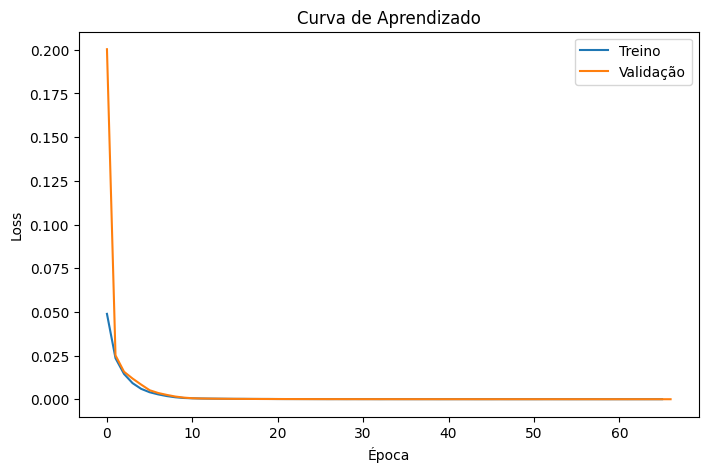

In [8]:
hist_train = melhor_trial.user_attrs["hist_train"]
hist_val = melhor_trial.user_attrs["hist_val"]

plt.figure(figsize=(8,5))
plt.plot(hist_train, label="Treino")
plt.plot(hist_val, label="Validação")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Curva de Aprendizado")
plt.legend()
plt.grid(False)

plt.show()

A análise ao longo das épocas mostra que o modelo aprendeu rapidamente nos estágios iniciais, com quedas significativas tanto no treino quanto na validação, e depois estabilizou-se em valores muito baixos. O loss da validação acompanha de perto o de treino, indicando boa generalização e ausência de under ou overfitting. Após as primeiras épocas, a loss se mantém praticamente constante, indicando que o modelo convergiu. Ou seja, ajustes adicionais não trazem melhorias significativas, refletindo consistência no aprendizado. Esse comportamento é evidenciado pelo acionamento do `Early Stopping` por volta da época 65, impedindo que o treinamento continue até o limite de 200 épocas.

# Treino do Modelo Final

Treinaremos agora o modelo final utilizando os melhores hiperparâmetros encontrados pelo Optuna.

In [9]:
melhores_params = study.best_trial.params

camadas_ocultas = [melhores_params[f"n_neuronios_l{i}"] for i in range(melhores_params["n_camadas"])]

if melhores_params["ativacao_oculta"] == "ReLU":
    ativacao = nn.ReLU()
elif melhores_params["ativacao_oculta"] == "Tanh":
    ativacao = nn.Tanh()
elif melhores_params["ativacao_oculta"] == "Sigmoid":
    ativacao = nn.Sigmoid()
else:
    ativacao = nn.LeakyReLU()

if melhores_params["ativacao_saida"] == "None":
    ativacao_saida = None
elif melhores_params["ativacao_saida"] == "ReLU":
    ativacao_saida = nn.ReLU()
else:
    ativacao_saida = nn.Softplus()

dm = DataModule(tamanho_lote=melhores_params["tamanho_lote"])
dm.setup(stage="fit")
num_features = dm.num_features
cat_dims = dm.cat_dims
emb_dims = [min(50, (c+1)//2) for c in cat_dims]

modelo = MLP(
    num_features=num_features,
    cat_dims=cat_dims,
    emb_dims=emb_dims,
    camadas_ocultas=camadas_ocultas,
    ativacao=ativacao,
    ativacao_saida=ativacao_saida,
    lr=melhores_params["lr"],
    weight_decay=melhores_params["weight_decay"],
    dropout=melhores_params["dropout"],
    use_batchnorm=melhores_params["batchnorm"],
    otimizador=melhores_params["optimizer"],
)

pasta_modelo = "Melhores modelos"
arquivo_modelo = "mlp_adamw.pth"
caminho_arquivo = os.path.join(pasta_modelo, arquivo_modelo)
os.makedirs(pasta_modelo, exist_ok=True)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=melhores_params["patience"],
    min_delta=1e-5,
    mode="min"
)

trainer = L.Trainer(
    max_epochs=epocas_maxima,
    callbacks=[early_stop],
    enable_checkpointing=False,
    logger=False,
    enable_progress_bar=True,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Os parâmetros treinados finais são salvos como `Melhores modelos/mlp_adamw.pth`, podendo ser carregados sem necessidade de treinar o modelo novamente.

In [10]:
if os.path.exists(caminho_arquivo):
    print("Parâmetros treinados já existem. Carregando o modelo...")
    modelo.load_state_dict(torch.load(caminho_arquivo))
    modelo.eval()
else:
    print("Parâmetros treinados não foram encontrados. Treinando o modelo...")
    modelo.train()
    trainer.fit(modelo, datamodule=dm)
    torch.save(modelo.state_dict(), caminho_arquivo)
    print(f"Modelo treinado e salvo em: {caminho_arquivo}")

Parâmetros treinados já existem. Carregando o modelo...


# Avaliação do Modelo Final

Podemos agora avaliar o modelo no conjunto de teste, tendo a sua performance medida pela métrica `RMSE`.

In [11]:
dm.setup("test")
X_num = dm.X_num_teste
X_cat = dm.X_cat_teste
y_true = dm.y_teste

with torch.no_grad():
    y_pred = modelo(X_num, X_cat)

y_true_orig = dm.y_scaler.inverse_transform(y_true)
y_pred_orig = dm.y_scaler.inverse_transform(y_pred)

RMSE_adamw = root_mean_squared_error(y_true_orig, y_pred_orig)
print(f"O RMSE do modelo MLP otimizado foi de {RMSE_adamw:.4f} unidades de y.")

O RMSE do modelo MLP otimizado foi de 1.3609 unidades de y.


# Comparação do desempenho com outro algoritmo

Para entender melhor o desempenho da MLP, optou-se por compará-la com outros algoritmos de predição: uma `Random Forest`, que foi construída e otimizada com base em um trabalho anterior [13], e um `Dummy Regressor`, utilizado apenas como baseline.

Otimizando os hiperparâmetros da `Random Forest`:

In [12]:
X_num_np = dm.X_num_treino.cpu().numpy()
X_cat_np = dm.X_cat_treino.cpu().numpy()
y_np = dm.y_treino.cpu().numpy().ravel()

X_num_test_np = dm.X_num_teste.cpu().numpy()
X_cat_test_np = dm.X_cat_teste.cpu().numpy()
y_test_np = dm.y_teste.cpu().numpy().ravel()

ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

X_cat_ohe_np = ohe.fit_transform(X_cat_np)
X_np = np.hstack([X_num_np, X_cat_ohe_np])

X_cat_test_ohe_np = ohe.transform(X_cat_test_np)
X_test_np = np.hstack([X_num_test_np, X_cat_test_ohe_np])

def cria_instancia_modelo_rf(trial):
    parametros_rf = {
        "n_estimators": trial.suggest_int("n_estimators", 5, 300, log=True),
        "criterion": trial.suggest_categorical(
            "criterion", ["squared_error", "absolute_error", "friedman_mse", "poisson"]
        ),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
        "max_features": trial.suggest_float("max_features", 0.0, 1.0),
        "bootstrap": True,
        "random_state": 2307,
        "n_jobs": -1
    }
    return RandomForestRegressor(**parametros_rf)

def objetivo_rf(trial, X, y, num_folds=5):
    modelo = cria_instancia_modelo_rf(trial)
    kf = KFold(n_splits=num_folds, shuffle=True, random_state=2307)
    
    scores = cross_val_score(
        modelo,
        X,
        y,
        cv=kf,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )
    return -scores.mean()

nome_do_estudo = "random_forest"
study_rf = optuna.create_study(
    direction="minimize",
    study_name=nome_do_estudo,
    storage=f"sqlite:///Estudos do Optuna/{nome_do_estudo}.db",
    load_if_exists=True
)

num_tentativas = 100
trials_ja_feitos = len(study_rf.trials)
if trials_ja_feitos < num_tentativas:
    study_rf.optimize(lambda trial: objetivo_rf(trial, X, y), n_trials=num_tentativas - trials_ja_feitos)

print("Melhores hiperparâmetros encontrados:")
print(study_rf.best_params)

[I 2026-04-06 21:21:17,326] Using an existing study with name 'random_forest' instead of creating a new one.


Melhores hiperparâmetros encontrados:
{'n_estimators': 297, 'criterion': 'poisson', 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 0.9265208601601265}


Treinando e avaliando o modelo com os melhores hiperparâmetros encontrado, utilizando como métrica o `RMSE`:

In [13]:
rf_params = study_rf.best_params

rf_final = RandomForestRegressor(**rf_params, random_state=2307, n_jobs=-1)
rf_final.fit(X_np, y_np)

y_pred_scaled_np = rf_final.predict(X_test_np)

y_pred_np = dm.y_scaler.inverse_transform(y_pred_scaled_np.reshape(-1,1)).ravel()
y_test_original_np = dm.y_scaler.inverse_transform(y_test_np.reshape(-1,1)).ravel()

RMSE_rf = np.sqrt(np.mean((y_test_original_np - y_pred_np)**2))
print(f"O RMSE do modelo Random Forest foi de {RMSE_rf:.4f} unidades de y.")

O RMSE do modelo Random Forest foi de 2.7549 unidades de y.


Treinando e avaliando o `Dummy Regressor`:

In [14]:
dummy = DummyRegressor(strategy="mean")
dummy.fit(X_np, y_np)

y_dummy_scaled_np = dummy.predict(X_test_np)

y_dummy_np = dm.y_scaler.inverse_transform(y_dummy_scaled_np.reshape(-1,1)).ravel()

RMSE_dummy = np.sqrt(np.mean((y_test_original_np - y_dummy_np)**2))
print(f"O RMSE do modelo Dummy Regressor foi de {RMSE_dummy:.4f} unidades de y.")

O RMSE do modelo Dummy Regressor foi de 51.3528 unidades de y.


# Análise da convergência de diferentes otimizadores

Decidiu-se comparar a convergência da MLP sob diferentes algoritmos de otimização, com o objetivo de analisar como cada método influencia a dinâmica de aprendizado ao longo das épocas. Foram avaliados os otimizadores Adam, AdamW e SGD no conjunto de melhores hiperparâmetros encontrados pelo Optuna.

Como o Optuna identificou o AdamW como melhor otimizador, este modelo já foi treinado anteriormente no "Treino do Modelo Final". Neste caso, podemos começar treinando o que utiliza Adam, sendo os parâmetros treinados aprendidos pelo modelo salvos em `Melhores modelos/mlp_adam.pth`.

In [15]:
otimizador_nome = "adam"

modelo = MLP(
    num_features=num_features,
    cat_dims=cat_dims,
    emb_dims=emb_dims,
    camadas_ocultas=camadas_ocultas,
    ativacao=ativacao,
    ativacao_saida=ativacao_saida,
    lr=melhores_params["lr"],
    weight_decay=melhores_params["weight_decay"],
    dropout=melhores_params["dropout"],
    use_batchnorm=melhores_params["batchnorm"],
    otimizador=otimizador_nome,
)

arquivo_modelo = "mlp_adam.pth"
caminho_arquivo = os.path.join(pasta_modelo, arquivo_modelo)

trainer_logger = L.Trainer(
    max_epochs=epocas_maxima,
    callbacks=[early_stop],
    enable_checkpointing=False,
    logger=True,
    log_every_n_steps=1,
    enable_progress_bar=True,
)

if os.path.exists(caminho_arquivo):
    print("Parâmetros treinados já existem. Carregando o modelo...")
    modelo.load_state_dict(torch.load(caminho_arquivo))
    modelo.eval()
else:
    print("Parâmetros treinados não foram encontrados. Treinando o modelo...")
    modelo.train()
    trainer_logger.fit(modelo, datamodule=dm)
    torch.save(modelo.state_dict(), caminho_arquivo)
    print(f"Modelo treinado e salvo em: {caminho_arquivo}")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/home/joao25017/miniconda3/envs/neuromante/lib/python3.14/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Parâmetros treinados já existem. Carregando o modelo...


Avaliando o modelo com Adam:

In [16]:
with torch.no_grad():
    y_pred = modelo(X_num, X_cat)

y_pred_orig = dm.y_scaler.inverse_transform(y_pred)

RMSE_adam = root_mean_squared_error(y_true_orig, y_pred_orig)
print(f"O RMSE do modelo MLP com otimizador Adam foi de {RMSE_adam:.4f} unidades de y.")

O RMSE do modelo MLP com otimizador Adam foi de 1.6142 unidades de y.


Fazendo a mesma coisa só que com o otimizador SGD, salvando os parâmetros finais aprendidos em `Melhores modelos/mlp_sgd.pth`.

In [17]:
otimizador_nome = "sgd"

modelo = MLP(
    num_features=num_features,
    cat_dims=cat_dims,
    emb_dims=emb_dims,
    camadas_ocultas=camadas_ocultas,
    ativacao=ativacao,
    ativacao_saida=ativacao_saida,
    lr=melhores_params["lr"],
    weight_decay=melhores_params["weight_decay"],
    dropout=melhores_params["dropout"],
    use_batchnorm=melhores_params["batchnorm"],
    otimizador=otimizador_nome,
)

arquivo_modelo = "mlp_sgd.pth"
caminho_arquivo = os.path.join(pasta_modelo, arquivo_modelo)

if os.path.exists(caminho_arquivo):
    print("Parâmetros treinados já existem. Carregando o modelo...")
    modelo.load_state_dict(torch.load(caminho_arquivo))
    modelo.eval()
else:
    print("Parâmetros treinados não foram encontrados. Treinando o modelo...")
    modelo.train()
    trainer_logger.fit(modelo, datamodule=dm)
    torch.save(modelo.state_dict(), caminho_arquivo)
    print(f"Modelo treinado e salvo em: {caminho_arquivo}")

Parâmetros treinados já existem. Carregando o modelo...


Avaliando o modelo com SGD:

In [18]:
with torch.no_grad():
    y_pred = modelo(X_num, X_cat)

y_pred_orig = dm.y_scaler.inverse_transform(y_pred)

RMSE_sgd = root_mean_squared_error(y_true_orig, y_pred_orig)
print(f"O RMSE do modelo MLP com otimizador SGD foi de {RMSE_sgd:.4f} unidades de y.")

O RMSE do modelo MLP com otimizador SGD foi de 37.0882 unidades de y.


Para analisar a convergência, podemos plottar a curva de aprendizado de cada modelo:

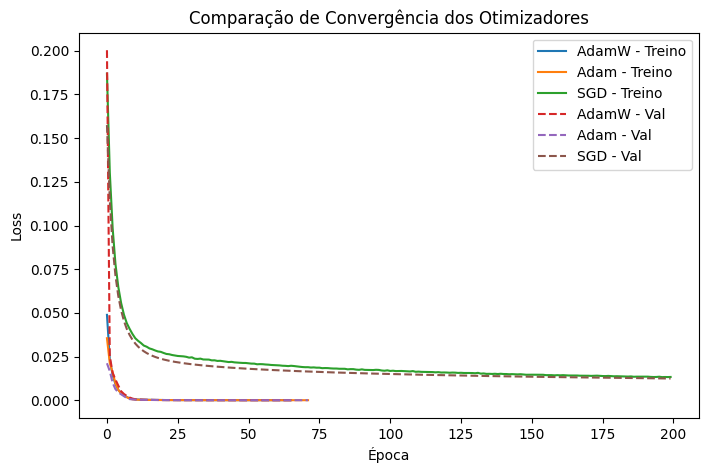

Última época Adam: 71
Última época SGD: 199
Última época AdamW: 65


In [19]:
loss_train_adamw = hist_train
loss_val_adamw = hist_val

metricas_adam = pd.read_csv("lightning_logs/version_3/metrics.csv")

metricas_adam_epoch = (
    metricas_adam
    .groupby("epoch", as_index=False)
    .mean(numeric_only=True)
)

loss_train_adam = metricas_adam_epoch["train_loss"].values
loss_val_adam = metricas_adam_epoch["val_loss"].values


metricas_sgd = pd.read_csv("lightning_logs/version_4/metrics.csv")

metricas_sgd_epoch = (
    metricas_sgd
    .groupby("epoch", as_index=False)
    .mean(numeric_only=True)
)

loss_train_sgd = metricas_sgd_epoch["train_loss"].values
loss_val_sgd = metricas_sgd_epoch["val_loss"].values

ultima_epoca_adam = metricas_adam["epoch"].max()

ultima_epoca_sgd = metricas_sgd["epoch"].max()

ultima_epoca_adamw = len(hist_train) - 1


plt.figure(figsize=(8,5))

plt.plot(loss_train_adamw, label="AdamW - Treino")
plt.plot(loss_train_adam, label="Adam - Treino")
plt.plot(loss_train_sgd, label="SGD - Treino")

plt.plot(loss_val_adamw, linestyle="--", label="AdamW - Val")
plt.plot(loss_val_adam, linestyle="--", label="Adam - Val")
plt.plot(loss_val_sgd, linestyle="--", label="SGD - Val")

plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Comparação de Convergência dos Otimizadores")
plt.legend()
plt.grid(False)

plt.show()

print(f"Última época Adam: {ultima_epoca_adam}")
print(f"Última época SGD: {ultima_epoca_sgd}")
print(f"Última época AdamW: {ultima_epoca_adamw}")

Observa-se que os otimizadores baseados em métodos adaptativos, como Adam e AdamW, convergiram em um número significativamente menor de época, enquanto o SGD utilizou todo o limite de treino. No caso do AdamW, é importante destacar que seu desempenho foi obtido a partir de uma otimização conjunta de hiperparâmetros via Optuna, na qual o próprio otimizador foi selecionado simultaneamente aos demais parâmetros do modelo. Isso implica que a escolha dos hiperparâmetros foi condicionada ao uso do AdamW, favorecendo uma configuração possivelmente mais ajustada a esse otimizador, fazendo a comparação se tornar parcialmente enviesada. Ainda assim, os resultados reforçam a tendência de que métodos adaptativos convergem mais rapidamente, enquanto o SGD apresenta uma dinâmica mais lenta nesse conjunto de dados.

# Explicação do modelo

A ferramenta de explicação de modelo utilizada é a `Permutation Importance`.

Ela é uma técnica utilizada para avaliar a relevância de cada variável em um modelo preditivo. A ideia consiste em embaralhar aleatoriamente os valores de uma feature e medir o quanto o desempenho do modelo piora; quanto maior a queda, mais importante é aquela variável para a predição. Esse método é independente do tipo de modelo e fornece uma interpretação intuitiva, embora possa ser sensível a correlações entre variáveis.

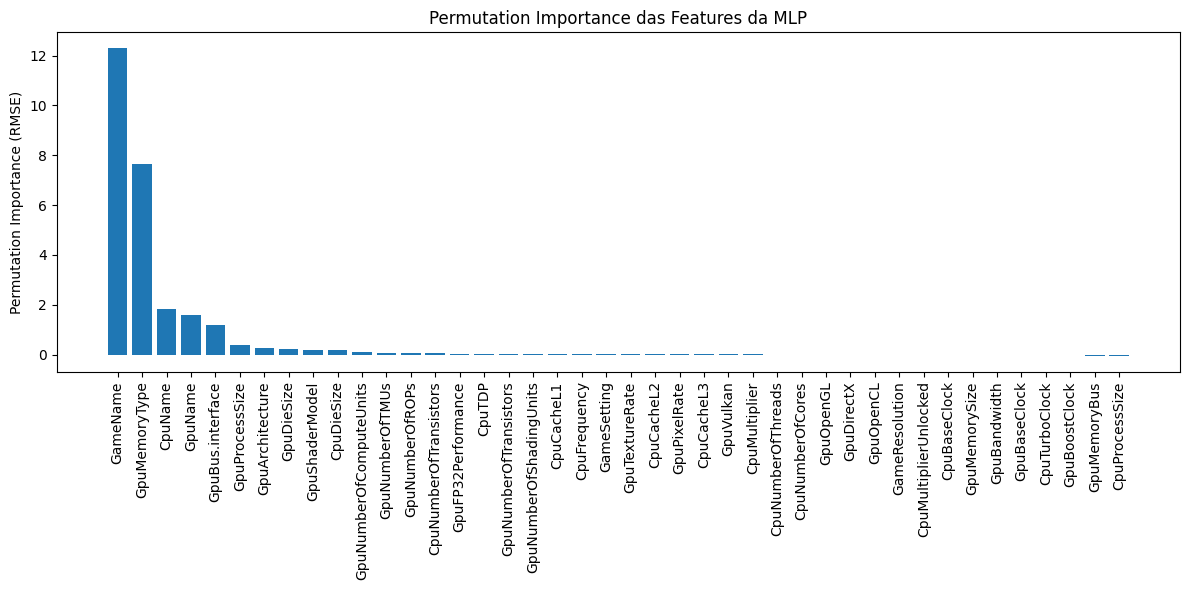

In [20]:
class MLPWrapperSklearn(BaseEstimator):
    def __init__(self, modelo, datamodule):
        self.modelo = modelo
        self.modelo.eval()
        self.dm = datamodule

    def fit(self, X=None, y=None):
        return self

    def predict(self, X):
        n_num = self.dm.X_num_teste.shape[1]
        X_num_tensor = torch.tensor(X[:, :n_num], dtype=torch.float32)
        X_cat_tensor = torch.tensor(X[:, n_num:], dtype=torch.long)
        with torch.no_grad():
            y_pred = self.modelo(X_num_tensor, X_cat_tensor)
        y_pred_orig = self.dm.y_scaler.inverse_transform(y_pred)
        return y_pred_orig.ravel()


model_wrapper = MLPWrapperSklearn(modelo, dm)

X_num = dm.X_num_teste.cpu().numpy()
X_cat = dm.X_cat_teste.cpu().numpy()
X_test_np = np.hstack([X_num, X_cat])
y_test_np = dm.y_scaler.inverse_transform(dm.y_teste).ravel()

result = permutation_importance(
    model_wrapper,
    X_test_np,
    y_test_np,
    n_repeats=10,
    random_state=2307,
    scoring='neg_root_mean_squared_error',
    n_jobs=1
)

num_feature_names = dm.num_col_names  # lista das colunas numéricas
cat_feature_names = dm.cat_col_names  # lista das colunas categóricas
feature_names = num_feature_names + cat_feature_names

importance_values = result.importances_mean

plt.figure(figsize=(12,6))
indices = np.argsort(importance_values)[::-1]
plt.bar(range(len(feature_names)), importance_values[indices])
plt.xticks(range(len(feature_names)), [feature_names[i] for i in indices], rotation=90)
plt.ylabel("Permutation Importance (RMSE)")
plt.title("Permutation Importance das Features da MLP")
plt.tight_layout()
plt.show()

Os resultados indicam que o modelo está excessivamente influenciado por algumas variáveis como `GameName`, `GpuName` e `CpuName`, sugerindo que ele aprendeu padrões específicos do dataset em vez de apenas relações físicas gerais. Ainda assim, ao observar as variáveis técnicas, fica claro que o desempenho está mais associado a características estruturais da GPU, como arquitetura, processo de fabricação (nm), tamanho do chip e paralelismo (compute units, ROPs, TMUs), do que a métricas isoladas como frequência. A CPU aparece com impacto menor, sendo mais relevante em termos de cache e complexidade do chip do que em clock, enquanto algumas variáveis com importância negativa indicam ruído ou redundância no modelo.

Um *insight*  que pode ser extraído desses resultados é que o desempenho depende principalmente da GPU, especialmente de suas características estruturais, como arquitetura, processo de fabricação (litografia) e número de unidades de processamento. Isso indica que ganhos reais vêm de avanços tecnológicos da placa, e não apenas de especificações superficiais ou nomes de modelo.

Portanto, se você pretende fazer um upgrade, o foco principal deve ser a GPU, escolhendo um modelo de arquitetura mais recente e com maior capacidade de processamento paralelo. A CPU pode ser considerada como complemento, priorizando melhorias de arquitetura e cache.

# Discussão dos resultados

Discutiremos os resultados obtidos de forma geral.

Primeiramente, analisaremos o resultado do modelo final otimizado por Optuna.

In [21]:
print(f"O RMSE do modelo MLP otimizado foi de {RMSE_adamw:.4f} unidades de y.")

O RMSE do modelo MLP otimizado foi de 1.3609 unidades de y.


O RMSE do modelo MLP otimizado foi de apenas 1.3609, indicando que as previsões estão muito próximas dos valores reais. Esse baixo erro sugere que o modelo aprendeu bem as relações presentes nos dados, oferecendo alta precisão. Considerando a escala de FPS do y, esse resultado demonstra que o MLP é eficaz e confiável para as previsões desejadas, refletindo o sucesso do processo de otimização. A curva de aprendizado, apresentada anteriormente, mostra que o modelo não apresentou overfitting nem underfitting.

Comparando com os RMSEs obtidos pelos outros algoritmos.

In [22]:
print(f"O RMSE do modelo Random Forest foi de {RMSE_rf:.4f} unidades de y.")
print(f"O RMSE do modelo Dummy Regressor foi de {RMSE_dummy:.4f} unidades de y.")

O RMSE do modelo Random Forest foi de 2.7549 unidades de y.
O RMSE do modelo Dummy Regressor foi de 51.3528 unidades de y.


O `Random Forest` apresentou um RMSE de 2.7549, indicando previsões razoavelmente próximas dos valores reais, mas ainda menos precisas que o MLP. Já o `Dummy Regressor` teve um RMSE de 51.3528, mostrando que é um modelo sem capacidade de aprendizado efetivo e que serve apenas como um baseline. Essa diferença reforça que o desempenho do MLP não é trivial.

Discutiremos agora a análise da convergência por diferentes otimizadores.

In [23]:
print(f"O RMSE do modelo MLP com otimizador Adam foi de {RMSE_adam:.4f} unidades de y.")
print(f"O RMSE do modelo MLP com otimizador SGD foi de {RMSE_sgd:.4f} unidades de y.")
print(f"O RMSE do modelo MLP com AdamW foi de {RMSE_adamw:.4f} unidades de y.")

print(f"Última época Adam: {ultima_epoca_adam}")
print(f"Última época SGD: {ultima_epoca_sgd}")
print(f"Última época AdamW: {ultima_epoca_adamw}")

O RMSE do modelo MLP com otimizador Adam foi de 1.6142 unidades de y.
O RMSE do modelo MLP com otimizador SGD foi de 37.0882 unidades de y.
O RMSE do modelo MLP com AdamW foi de 1.3609 unidades de y.
Última época Adam: 71
Última época SGD: 199
Última época AdamW: 65


Esses resultados mostram diferenças significativas em desempenho e velocidade de convergência. O modelo treinado com `Adam` atingiu um RMSE de 1.6142 em 71 épocas, enquanto o `SGD` resultou em um RMSE muito maior, de 37.0882, mesmo após 199 épocas. Já o `AdamW` concluiu o treinamento em 65 épocas, mostrando convergência rápida e obtendo o melhor RMSE, de 1.3609. É importante destacar que o desempenho do `AdamW` foi obtido a partir de uma otimização conjunta de hiperparâmetros via Optuna, na qual o próprio otimizador foi selecionado simultaneamente aos demais parâmetros do modelo. Isso implica que a escolha dos hiperparâmetros foi condicionada ao uso do `AdamW`, favorecendo uma configuração possivelmente mais ajustada a esse otimizador e tornando a comparação parcialmente enviesada. Ainda assim, os resultados reforçam a tendência de que métodos adaptativos, como `Adam` e `AdamW`, convergem mais rapidamente, enquanto o `SGD` apresenta uma dinâmica mais lenta neste conjunto de dados. O gráfico apresentado acima auxilia na visualização dessa análise.

Por fim, a análise da `Permutation Importance` mostra que o modelo apresenta forte influência de variáveis como `GameName`, `GpuName` e `CpuName`, indicando aprendizado de padrões específicos do dataset. O desempenho depende principalmente da GPU, especialmente arquitetura, litografia e unidades de processamento, enquanto a CPU tem impacto menor, ligado a cache e complexidade do chip. Com base nisso, conseguimos o *insight* de que, para upgrades, é melhor priorizar GPUs mais modernas e com maior paralelismo, enquanto a CPU deve ser considerada apenas como complemento.

# Conclusão

O estudo demonstrou que a `MLP` é uma rede neural eficiente para predição de dados tabulados, apresentando baixo RMSE na avaliação. Ficou evidente que a otimização de hiperparâmetros com Optuna pode melhorar significativamente o desempenho, especialmente quando a escolha do otimizador, função de ativação e técnicas de regularização são consideradas de forma integrada. A análise de convergência mostrou que métodos adaptativos, como `Adam` e `AdamW`, favorecem treinamentos mais rápidos e estáveis, enquanto escolhas inadequadas, como o uso do `SGD` nas condições testadas, comprometem a precisão e a velocidade de aprendizado.

Além disso, a análise das variáveis mais influentes mostrou que o FPS está fortemente ligado a características estruturais da GPU, enquanto a CPU exerce impacto menor. Isso permite extrair o *insight* prático de que, para upgrades, priorizar GPUs modernas com maior paralelismo traz ganhos mais significativos. 

De modo geral, o estudo evidencia que a escolha adequada de hiperparâmetros, otimizadores, funções de ativação e técnicas de regularização é determinante para a precisão e a convergência do `MLP`, reforçando sua sensibilidade a configurações e seu potencial quando corretamente ajustado.

# Referências 

[1] **fps_benchmark**. Disponível em: <https://www.openml.org/search?type=data&status=active&id=44992>.

[2] **ATP-303 NN 3.2 - Construindo e treinando redes neurais com PyTorch e Lightning** - Daniel R. Cassar

[3] **PyTorch Embedding Layer for Categorical Data** - Medium. Disponível em: <https://medium.com/biased-algorithms/pytorch-embedding-layer-for-categorical-data-096af5757353>.

[4] **Multi-layer Perceptron** - the hallway. Disponível em: <https://the-hallway.jakereynolds.co/neural-networks/types/multi-layer-perceptron/>.

[5] **Regularization In Neural Networks** - Towards Data Science. Disponível em: <https://towardsdatascience.com/regularisation-techniques-neural-networks-101-1f746ad45b72/>.

[6] **Batch Normalization for Training Neural Networks (with PyTorch)** - Medium. Disponível em: <https://medium.com/thedeephub/batch-normalization-for-training-neural-networks-328112bda3ae>.

[7] **Weight Decay and Its Peculiar Effects** - Towards Data Science. Disponível em: <https://towardsdatascience.com/weight-decay-and-its-peculiar-effects-66e0aee3e7b8/>.

[8] **Stochastic Gradient Descent (SGD): A Comprehensive Guide to Faster Machine Learning** - Medium. Disponível em: <https://medium.com/@lomashbhuva/stochastic-gradient-descent-sgd-a-comprehensive-guide-to-faster-machine-learning-b3afaf496a52>.

[9] **Adam vs. AdamW: Understanding Weight Decay and Its Impact on Model Performance** - Medium. Disponível em: <https://yassin01.medium.com/adam-vs-adamw-understanding-weight-decay-and-its-impact-on-model-performance-b7414f0af8a1>.

[10] **12 Types of Activation Functions in Neural Networks: A Comprehensive Guide** - Medium Disponível em: <https://medium.com/@sushmita2310/12-types-of-activation-functions-in-neural-networks-a-comprehensive-guide-a441ecefb439>.

[11] **Softplus function — Smooth approximation of the ReLU function** - NeuralThreads. Disponível em: <https://neuralthreads.medium.com/softplus-function-smooth-approximation-of-the-relu-function-6a85f92a98e6>.

[12] **Lilly Tech Systems Deep Learning Course** Disponível em: <https://lillytechsystems.com/ai-school/deep-learning/training.html>.

[13] **Proton-Collision-Classifier** - ComicDeath. Disponível em: <https://github.com/ComicDeath/Proton-Collision-Classifier>.